### Imports

In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

import warnings
warnings.filterwarnings("ignore")

### Load Data 

In [5]:
white_wine_data = pd.read_csv(r"..\wine_data\winequality-white.csv", sep=";")
red_wine_data = pd.read_csv(r"..\wine_data\winequality-red.csv", sep=";")

white_wine_data.columns = white_wine_data.columns.str.strip().str.lower().str.replace(" ", "_")
red_wine_data.columns = red_wine_data.columns.str.strip().str.lower().str.replace(" ", "_")

white_wine_data['type'] = 'white'
red_wine_data['type'] = 'red'

wine_data_frame = pd.concat([white_wine_data, red_wine_data], ignore_index=True)

print(f"Shape: {wine_data_frame.shape}")
print(wine_data_frame.head(5).round(3).to_string())

Shape: (6497, 13)
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  free_sulfur_dioxide  total_sulfur_dioxide  density    ph  sulphates  alcohol  quality   type
0            7.0              0.27         0.36            20.7      0.045                 45.0                 170.0    1.001  3.00       0.45      8.8        6  white
1            6.3              0.30         0.34             1.6      0.049                 14.0                 132.0    0.994  3.30       0.49      9.5        6  white
2            8.1              0.28         0.40             6.9      0.050                 30.0                  97.0    0.995  3.26       0.44     10.1        6  white
3            7.2              0.23         0.32             8.5      0.058                 47.0                 186.0    0.996  3.19       0.40      9.9        6  white
4            7.2              0.23         0.32             8.5      0.058                 47.0                 186.0    0.996  3.19     

### Basic Info

In [7]:
print(wine_data_frame.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   ph                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None


In [8]:
print("\nMissing values")
print(wine_data_frame.isnull().sum())


Missing values
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
ph                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


In [9]:
print("\nBasic Statistics")
print(wine_data_frame.describe().round(3).to_string())


Basic Statistics
       fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  free_sulfur_dioxide  total_sulfur_dioxide   density        ph  sulphates   alcohol   quality
count       6497.000          6497.000     6497.000        6497.000   6497.000             6497.000              6497.000  6497.000  6497.000   6497.000  6497.000  6497.000
mean           7.215             0.340        0.319           5.443      0.056               30.525               115.745     0.995     3.219      0.531    10.492     5.818
std            1.296             0.165        0.145           4.758      0.035               17.749                56.522     0.003     0.161      0.149     1.193     0.873
min            3.800             0.080        0.000           0.600      0.009                1.000                 6.000     0.987     2.720      0.220     8.000     3.000
25%            6.400             0.230        0.250           1.800      0.038               17.000                77

### Wine Type Distribution

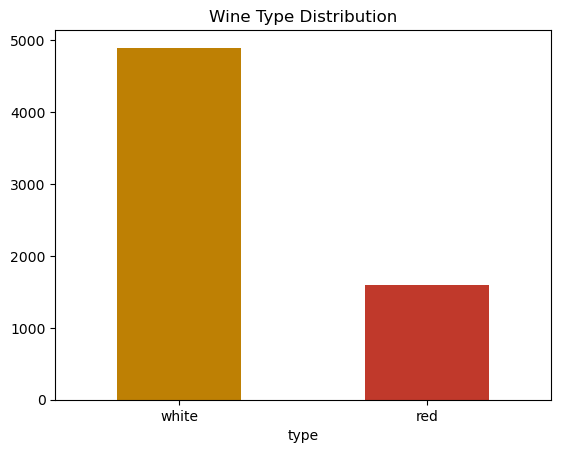

White Wine count 4898 
Red Wine count 1599


In [10]:
wine_type_counts = wine_data_frame["type"].value_counts()

wine_type_counts.plot(kind="bar", color=["#BE8004", "#C0392B"])
plt.title("Wine Type Distribution")
plt.xticks(rotation=0)
plt.savefig("../figures/eda_figures/fig1_wine_type_distribution.png", bbox_inches='tight')
plt.show()

print(f"White Wine count {wine_type_counts["white"]} \nRed Wine count {wine_type_counts["red"]}")

### Quality Distribution

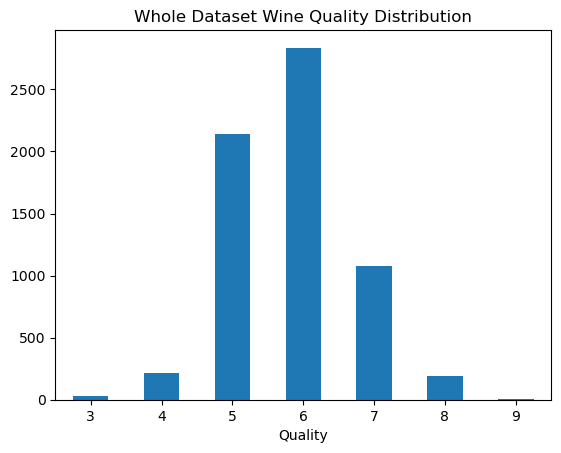

In [11]:
wine_data_frame["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Whole Dataset Wine Quality Distribution")
plt.xlabel("Quality")
plt.xticks(rotation=0)
plt.savefig("../figures/eda_figures/fig2_wine_quality_distribution.png", bbox_inches='tight')
plt.show()


In [12]:
print((wine_data_frame['quality'] == 5).sum())
print((wine_data_frame['quality'] == 6).sum())

2138
2836


### Red vs. White Wine Quality Distribution

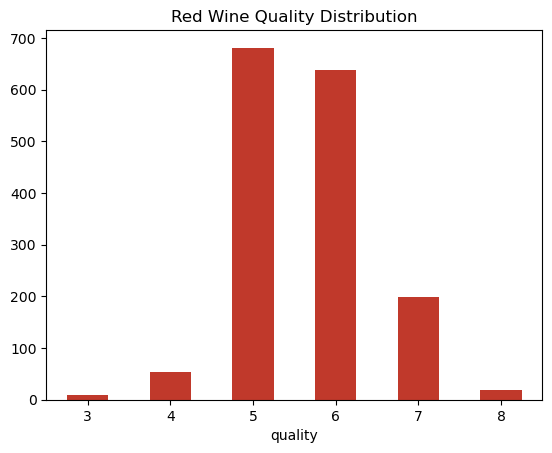

In [13]:
red_wine_data["quality"].value_counts().sort_index().plot(kind="bar", color="#C0392B")
plt.title("Red Wine Quality Distribution")
plt.xticks(rotation=0)
plt.savefig("../figures/eda_figures/fig3_red_wine_quality_distribution.png", bbox_inches='tight')
plt.show()

In [14]:
print((red_wine_data['quality'] == 5).sum())
print((red_wine_data['quality'] == 6).sum())

681
638


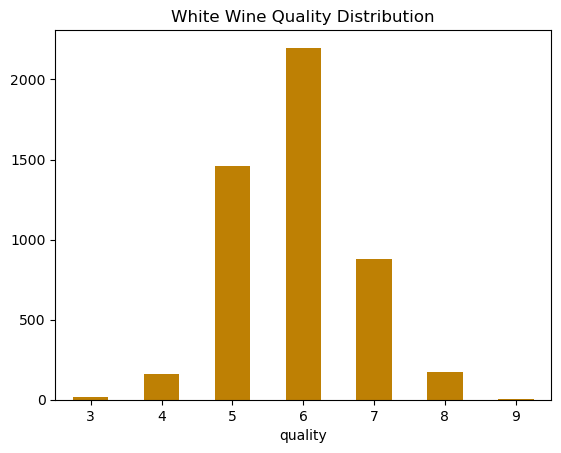

In [15]:
white_wine_data["quality"].value_counts().sort_index().plot(kind="bar", color="#BE8004")
plt.title("White Wine Quality Distribution")
plt.xticks(rotation=0)
plt.savefig("../figures/eda_figures/fig4_white_wine_quality_distribution.png", bbox_inches='tight')
plt.show()

In [16]:
print((white_wine_data['quality'] == 5).sum())
print((white_wine_data['quality'] == 6).sum())

1457
2198


### Grouping Quality Scores

In [17]:
def group_quality_scores(score):
    if score <= 4:
        return "low"
    elif score <= 6:
        return "medium"
    elif score <= 9:
        return "high"
    else:
        return None

wine_data_frame["quality_group"] = wine_data_frame["quality"].apply(group_quality_scores)
print(wine_data_frame.groupby("type")["quality_group"].value_counts(normalize=True).round(2))

type   quality_group
red    medium           0.82
       high             0.14
       low              0.04
white  medium           0.75
       high             0.22
       low              0.04
Name: proportion, dtype: float64


### Quality Correlation Across Chemical Features

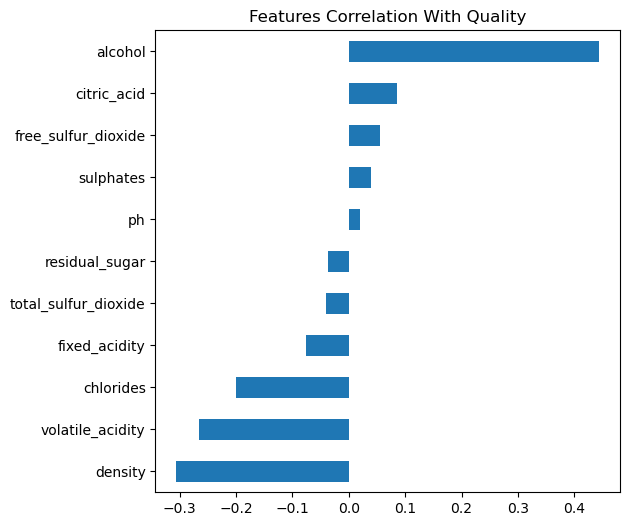


Top features:
alcohol             0.44
density             0.31
volatile_acidity    0.27
chlorides           0.20
citric_acid         0.09
dtype: float64


In [18]:
features = wine_data_frame.drop(columns=["type", "quality", "quality_group"])

correlation = features.corrwith(wine_data_frame["quality"]).sort_values()

correlation.plot(kind="barh", figsize=(6,6))
plt.title("Features Correlation With Quality")
plt.savefig("../figures/eda_figures/fig5_wine_quality_correlation.png", bbox_inches='tight')
plt.show()

print("\nTop features:")
print(round(correlation.abs().sort_values(ascending=False).head(5), 2))

### Correaltion Heatmap Across All Features

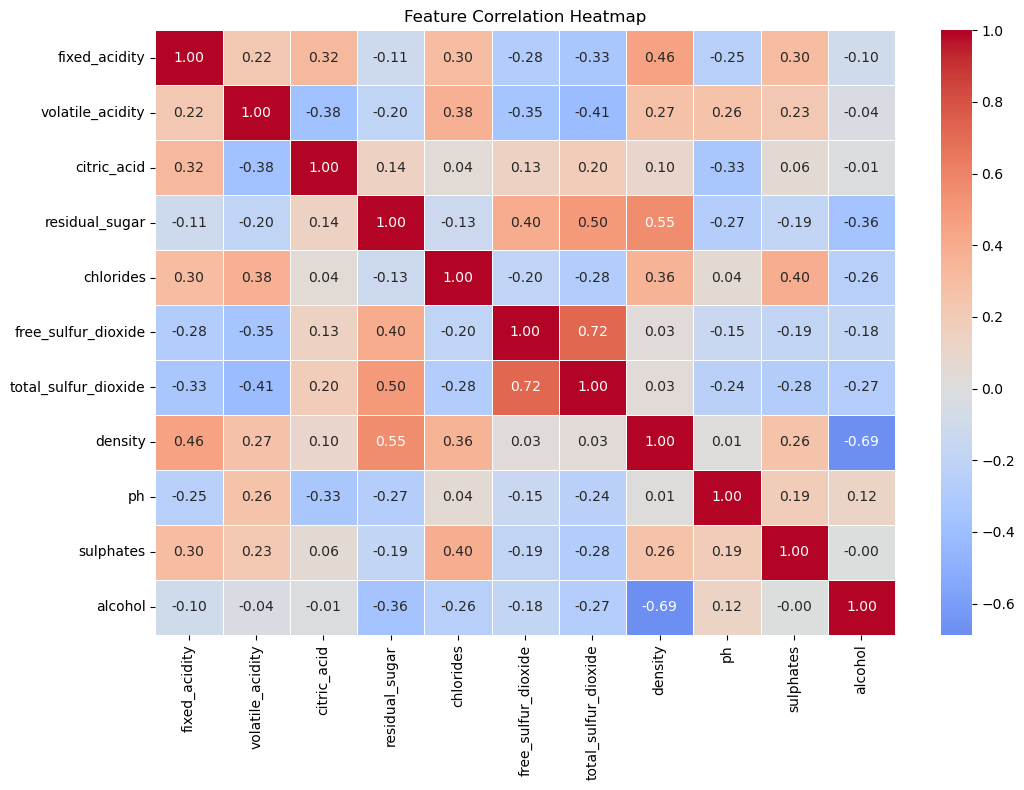

In [19]:
plt.figure(figsize=(11, 8))

correlation_matrix = features.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("../figures/eda_figures/fig6_wine_features_correlations.png", bbox_inches='tight')
plt.show()

### Box Plots showing how key features differ across quality groups

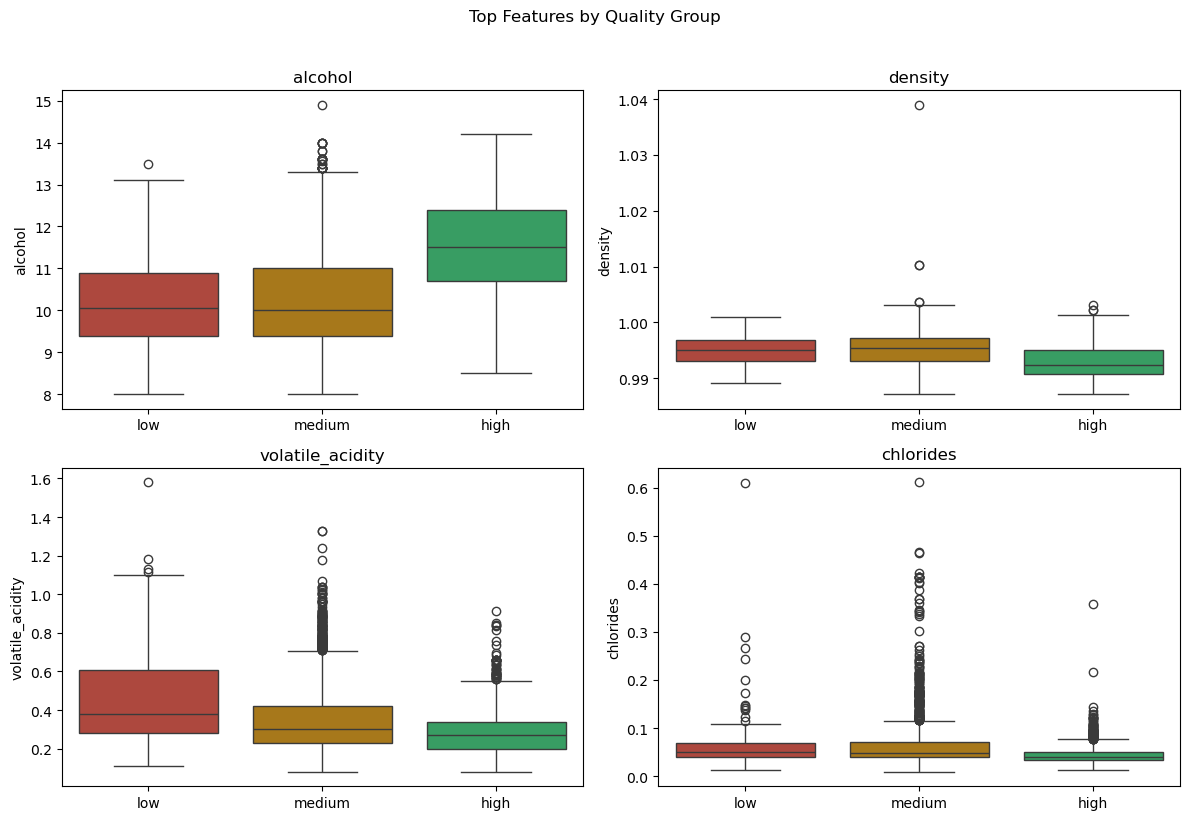

In [20]:
top_features = correlation.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

order = ["low", "medium", "high"]

for i, feature in enumerate(top_features):
    sns.boxplot(
        data=wine_data_frame,
        x="quality_group",
        y=feature,
        order=order,
        palette=["#c0392b", "#BE8004", "#27ae60"],
        ax=axes[i]
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel("")

plt.suptitle("Top Features by Quality Group", y=1.02)
plt.tight_layout()
plt.savefig("../figures/eda_figures/fig7_wine_type_differences_across_features.png", bbox_inches='tight')
plt.show()

### Alcohol by wine type

        count   mean   std  min  25%   50%   75%   max
type                                                  
red    1599.0  10.42  1.07  8.4  9.5  10.2  11.1  14.9
white  4898.0  10.51  1.23  8.0  9.5  10.4  11.4  14.2

Mann-Whitney p-value: 0.18185
result: no significant difference found


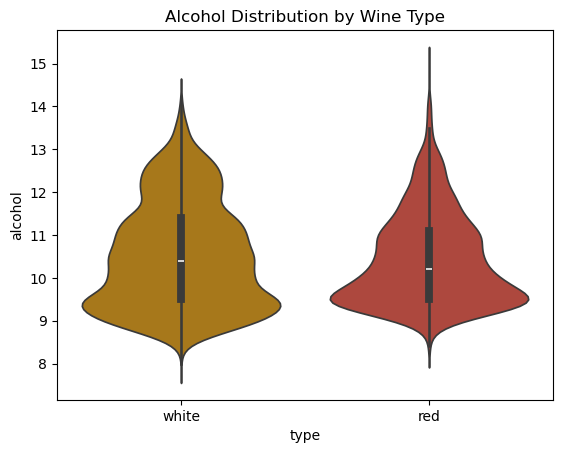

In [21]:
print(wine_data_frame.groupby("type")["alcohol"].describe().round(2))

u, p = mannwhitneyu(red_wine_data["alcohol"], white_wine_data["alcohol"])
print("\nMann-Whitney p-value:", round(p, 5))

if p < 0.05:
    print("result: statistically significant difference in alcohol between red and white wines")
else:
    print("result: no significant difference found")

# also visualise it
sns.violinplot(
    data=wine_data_frame,
    x="type",
    y="alcohol",
    palette={"red": "#c0392b", "white": "#BE8004"}
)
plt.title("Alcohol Distribution by Wine Type")
plt.savefig("../figures/eda_figures/fig8_alcohol_distribution_by_wine_type.png", bbox_inches='tight')
plt.show()

### Outliers per Feature

In [22]:
outlier_percentage = {}

for col in features.columns:
    q1 = wine_data_frame[col].quantile(0.25)
    q3 = wine_data_frame[col].quantile(0.75)
    iqr = q3 - q1

    outliers = wine_data_frame[(wine_data_frame[col] < q1 - 1.5 * iqr) | (wine_data_frame[col] > q3 + 1.5 * iqr)]
    outlier_percentage[col] = len(outliers) / len(wine_data_frame)

outlier_pct = pd.Series(outlier_percentage).sort_values(ascending=False)

print("outlier % per feature:")
print((outlier_pct * 100).round(2))

# decision: outliers are kept because they likely represent
# genuinely extreme but real wines, not data entry errors.
# removing them could delete valid edge cases for low/high quality
print("\noutliers kept in dataset - assumed to be real measurements")

outlier % per feature:
citric_acid             7.83
volatile_acidity        5.80
fixed_acidity           5.49
chlorides               4.40
sulphates               2.94
residual_sugar          1.82
ph                      1.12
free_sulfur_dioxide     0.95
total_sulfur_dioxide    0.15
density                 0.05
alcohol                 0.05
dtype: float64

outliers kept in dataset - assumed to be real measurements


### Dataset Summary

In [23]:
print("rows:", len(wine_data_frame))
print("features:", len(features.columns))
print("missing values:", wine_data_frame.isnull().sum().sum())
print("quality range:", wine_data_frame["quality"].min(), "-", wine_data_frame["quality"].max())
print("most common quality score:", wine_data_frame["quality"].mode()[0])
print("\nclass distribution:")
print(wine_data_frame["quality_group"].value_counts())
print("\nmedium quality dominates - class imbalance will need to be handled in modelling")

rows: 6497
features: 11
missing values: 0
quality range: 3 - 9
most common quality score: 6

class distribution:
quality_group
medium    4974
high      1277
low        246
Name: count, dtype: int64

medium quality dominates - class imbalance will need to be handled in modelling
